In [1]:
#import librariers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
#loading dataset

df = pd.read_csv("C:/Users/Bomma/Downloads/Gen AI Materials/Project/Customer_Retention_Edutech.csv")

df_original = df.copy()

In [9]:
#basic EDA
df.head()


,Age,Gender,City,Device_Type,Avg_Session_Time,Pages_Visited,Course_Category,Subscription_Type,Last_Activity_Days,Email_Click_Rate,Previous_Purchases,Support_Tickets,Satisfaction_Score,Churn
0,56,Other,Mumbai,Tablet,22.94,8,Business,Basic,53,0.98,8,4,5,0
1,46,Male,Mumbai,Desktop,17.95,10,Data Science,Free,27,0.02,9,4,1,0
2,32,Male,Hyderabad,Tablet,2.56,1,Web Dev,Premium,36,0.09,0,4,3,0
3,25,Female,Bangalore,Mobile,26.81,5,Design,Premium,19,0.50,3,2,3,0
4,38,Female,Bangalore,Tablet,9.86,15,Web Dev,Free,34,0.34,8,1,3,1


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 10000 non-null  int64  
 1   Gender              10000 non-null  object 
 2   City                10000 non-null  object 
 3   Device_Type         10000 non-null  object 
 4   Avg_Session_Time    10000 non-null  float64
 5   Pages_Visited       10000 non-null  int64  
 6   Course_Category     10000 non-null  object 
 7   Subscription_Type   10000 non-null  object 
 8   Last_Activity_Days  10000 non-null  int64  
 9   Email_Click_Rate    10000 non-null  float64
 10  Previous_Purchases  10000 non-null  int64  
 11  Support_Tickets     10000 non-null  int64  
 12  Satisfaction_Score  10000 non-null  int64  
 13  Churn               10000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 1.1+ MB


In [13]:
df.describe()



,Age,Avg_Session_Time,Pages_Visited,Last_Activity_Days,Email_Click_Rate,Previous_Purchases,Support_Tickets,Satisfaction_Score,Churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,38.546400,15.444372,9.952300,29.474700,0.501910,4.546700,2.019300,2.993800,0.29450
std,12.014287,8.369579,5.464724,17.188627,0.287232,2.866922,1.409229,1.422942,0.45584
min,18.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000
25%,28.000000,8.160000,5.000000,15.000000,0.250000,2.000000,1.000000,2.000000,0.00000
50%,39.000000,15.500000,10.000000,29.000000,0.500000,5.000000,2.000000,3.000000,0.00000
75%,49.000000,22.650000,15.000000,44.000000,0.750000,7.000000,3.000000,4.000000,1.00000
max,59.000000,29.990000,19.000000,59.000000,1.000000,9.000000,4.000000,5.000000,1.00000


In [17]:
df.isnull().sum()
 #to check if any nulls present

Age                   0
Gender                0
City                  0
Device_Type           0
Avg_Session_Time      0
Pages_Visited         0
Course_Category       0
Subscription_Type     0
Last_Activity_Days    0
Email_Click_Rate      0
Previous_Purchases    0
Support_Tickets       0
Satisfaction_Score    0
Churn                 0
dtype: int64

In [19]:
df.duplicated().sum()

0

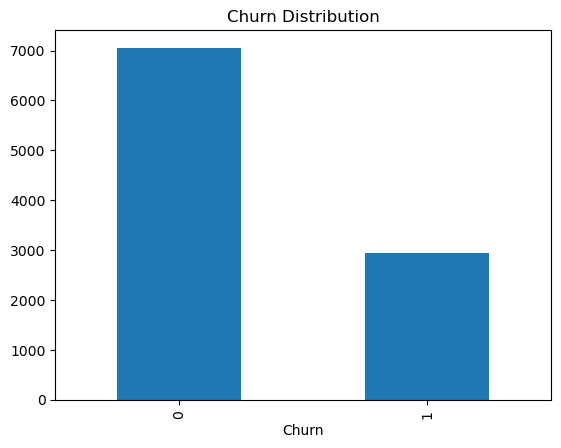

In [21]:
#plotting

df['Churn'].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

In [ ]:
# Slightly imbalanced 
# Churn is low 
# 0 ----> Not Churned
# 1 ----> Churned

In [23]:
df.Course_Category.value_counts()

Course_Category
Business        2067
Data Science    2028
Web Dev         1986
Design          1960
AI/ML           1959
Name: count, dtype: int64

In [25]:
df.columns

Index(['Age', 'Gender', 'City', 'Device_Type', 'Avg_Session_Time',
       'Pages_Visited', 'Course_Category', 'Subscription_Type',
       'Last_Activity_Days', 'Email_Click_Rate', 'Previous_Purchases',
       'Support_Tickets', 'Satisfaction_Score', 'Churn'],
      dtype='object')

In [27]:
df.Subscription_Type.value_counts()

Subscription_Type
Basic      3400
Free       3305
Premium    3295
Name: count, dtype: int64

In [29]:
df.Device_Type.value_counts()

Device_Type
Tablet     3383
Mobile     3329
Desktop    3288
Name: count, dtype: int64

In [31]:
df.City.value_counts()

City
Delhi        2074
Chennai      2053
Hyderabad    1993
Bangalore    1956
Mumbai       1924
Name: count, dtype: int64

In [33]:
df.duplicated().sum()  #to check if we have any duplicates

0

In [35]:
df.shape

(10000, 14)

In [37]:
categorical = [x for x in df.columns if df[x].dtype=='O'] ## list comprehension  ## checking for the datatype of the column

print('There are {} categorical variables\n'.format(len(categorical)))  ## how many categorical var are there 

print('The categorical variables are :\n\n', categorical)

There are 5 categorical variables

The categorical variables are :

 ['Gender', 'City', 'Device_Type', 'Course_Category', 'Subscription_Type']


In [39]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {count} outliers")

Age: 0 outliers
Avg_Session_Time: 0 outliers
Pages_Visited: 0 outliers
Last_Activity_Days: 0 outliers
Email_Click_Rate: 0 outliers
Previous_Purchases: 0 outliers
Support_Tickets: 0 outliers
Satisfaction_Score: 0 outliers
Churn: 0 outliers


In [41]:
# to check outliers in my numerical columns using IQR method
# no outliers detected

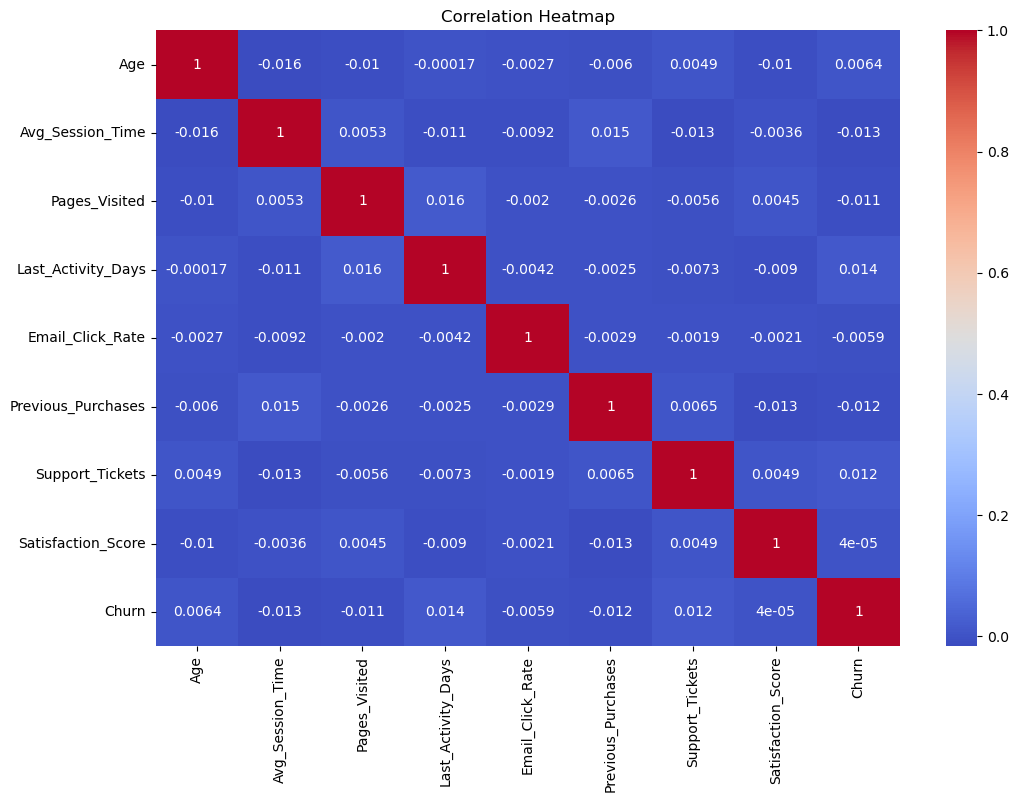

Churn                 1.000000
Last_Activity_Days    0.013696
Support_Tickets       0.012169
Age                   0.006371
Satisfaction_Score    0.000040
Email_Click_Rate     -0.005931
Pages_Visited        -0.010901
Previous_Purchases   -0.011558
Avg_Session_Time     -0.012781
Name: Churn, dtype: float64

In [43]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

corr_matrix['Churn'].sort_values(ascending=False)  # to check only with target feature how it is correlated with other features

In [45]:
# this shows churn is high when least active days,satisfaction score is less,avg session time is less

#checking for categorical data 

Churn,0,1
Gender,,
Female,70.191159,29.808841
Male,71.186953,28.813047
Other,70.278360,29.721640


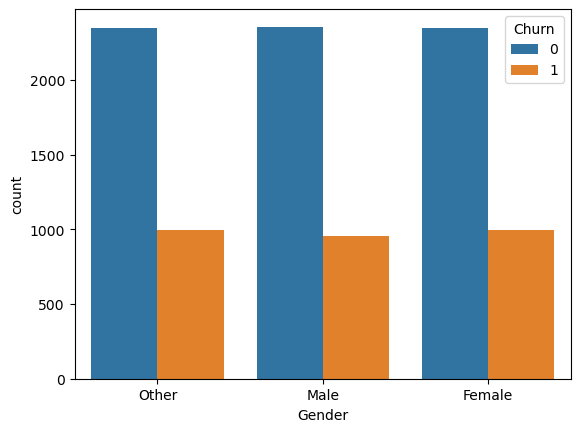

In [47]:

sns.countplot(x='Gender', hue='Churn', data=df)

pd.crosstab(df['Gender'], df['Churn'], normalize='index') * 100

Churn,0,1
City,,
Bangalore,71.114519,28.885481
Chennai,70.384803,29.615197
Delhi,71.215043,28.784957
Hyderabad,70.145509,29.854491
Mumbai,69.854470,30.145530


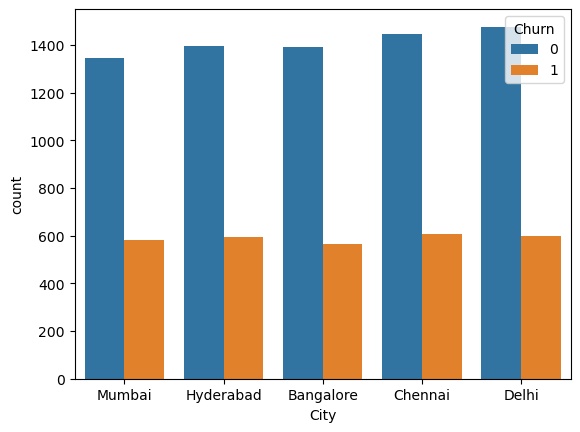

In [49]:
sns.countplot(x='City', hue='Churn', data=df)

pd.crosstab(df['City'], df['Churn'], normalize='index') * 100

Churn,0,1
Subscription_Type,,
Basic,71.058824,28.941176
Free,70.801815,29.198185
Premium,69.772382,30.227618


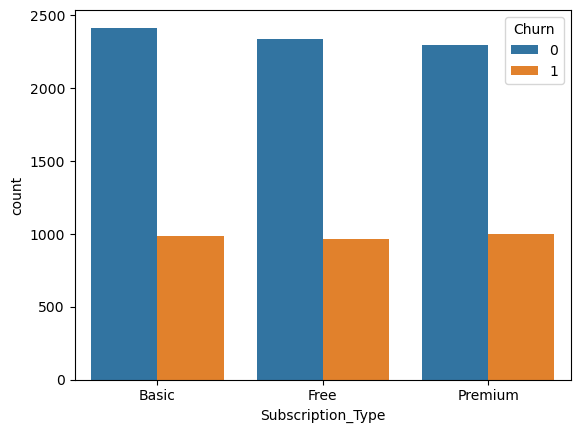

In [51]:
sns.countplot(x='Subscription_Type', hue='Churn', data=df)

pd.crosstab(df['Subscription_Type'], df['Churn'], normalize='index') * 100

Churn,0,1
Course_Category,,
AI/ML,68.912711,31.087289
Business,70.730527,29.269473
Data Science,71.646943,28.353057
Design,71.020408,28.979592
Web Dev,70.392749,29.607251


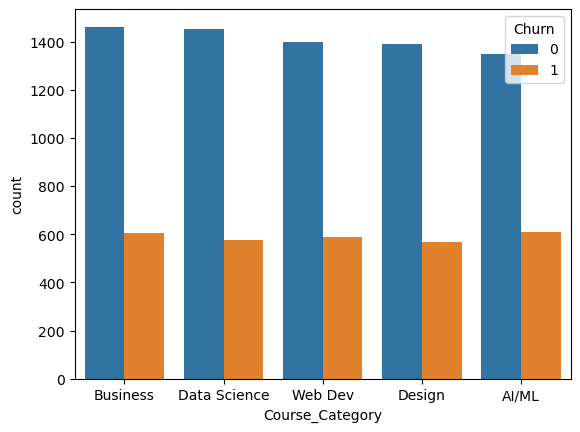

In [53]:
sns.countplot(x='Course_Category', hue='Churn', data=df)

pd.crosstab(df['Course_Category'], df['Churn'], normalize='index') * 100

Churn,0,1
Satisfaction_Score,,
1,69.887750,30.112250
2,71.789687,28.210313
3,69.668008,30.331992
4,71.370143,28.629857
5,70.083785,29.916215


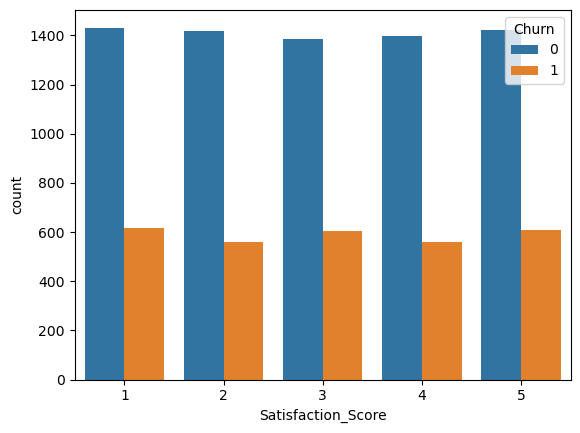

In [55]:
sns.countplot(x='Satisfaction_Score', hue='Churn', data=df)

pd.crosstab(df['Satisfaction_Score'], df['Churn'], normalize='index') * 100

In [57]:
#from above graph we can conlude
# 1)more churn is between Others in Gender
# 2) More Churn we can see from Hyderabad then Delhi
# 3)Basic Subscription churned most then comes premium subscription
# 4) Highest churn is for data science then comes Web development
# 5) highest churn is more satisfaction score 2 an dthen satisfaction score 1

In [59]:
#Feature Engineering
# Label Encoding ---> when binary / ordinal (Gender,Subscription_Type)
# One hot Encoding ----> when no order (City,Device_Type,Course_Category)

In [129]:
le_gender = LabelEncoder()
le_sub = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])
df['Subscription_Type'] = le_sub.fit_transform(df['Subscription_Type'])

In [131]:
print(le_gender.classes_)

[0 1 2]


In [71]:
df.Gender.value_counts()

Gender
0    3348
2    3341
1    3311
Name: count, dtype: int64

In [73]:
# Save encoders
pickle.dump(le_gender, open('le_gender.pkl', 'wb'))
pickle.dump(le_sub, open('le_sub.pkl', 'wb'))

In [65]:
#now we are doing one hot encoding for City,Device_Type,Course_Category

In [75]:
# one hot Encoding 
#drop_first=True, one category is treated as a baseline, and the remaining categories are represented relative to it, reducing multicollinearity

df = pd.get_dummies(df,columns=['City', 'Device_Type', 'Course_Category'],drop_first=True,dtype = int)

In [77]:
#If data has outliers → use StandardScaler
#If data is clean and needs normalization → use MinMaxScaler”

#if ur unsure always best to go with standardscaler 
# applicable when such as linear regression, logistic regression, and neural networks.

In [79]:
#before scaling lets first split our data because it might learn from entire data including test set

In [81]:
#data shuffles everytime to stop shuffling we take random_state.

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [83]:
# Numerical columns to sclae
num_cols = ['Age','Avg_Session_Time','Pages_Visited','Last_Activity_Days',
            'Email_Click_Rate','Previous_Purchases','Support_Tickets','Satisfaction_Score']

#Scaling
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])   # fit + transform selected columns
X_test[num_cols] = scaler.transform(X_test[num_cols])          # only transform

In [85]:
# SAVE SCALER HERE 
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [87]:

X_train[num_cols].head()  #checking numerical columns scaled 

,Age,Avg_Session_Time,Pages_Visited,Last_Activity_Days,Email_Click_Rate,Previous_Purchases,Support_Tickets,Satisfaction_Score
9254,-0.539126,-0.062066,-1.628768,-0.961277,0.031442,1.197609,-1.431491,-0.704763
1561,0.378571,0.066862,-1.263035,-0.611359,-1.225383,-0.896266,-0.011449,-1.408383
1670,1.629974,-1.070813,-1.263035,1.604792,-0.911176,-0.198307,-1.431491,1.406096
6087,0.295144,1.118585,-0.714436,1.663112,0.136178,-0.198307,0.698572,-1.408383
6669,-0.288845,0.038211,-1.445902,0.321757,0.450384,0.848630,0.698572,1.406096


In [89]:
X_train[num_cols].std() #should be close to 1

Age                   1.000063
Avg_Session_Time      1.000063
Pages_Visited         1.000063
Last_Activity_Days    1.000063
Email_Click_Rate      1.000063
Previous_Purchases    1.000063
Support_Tickets       1.000063
Satisfaction_Score    1.000063
dtype: float64

In [93]:
# Initialize models at once logistic,randomforest,xgboost
# Initialize models

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Train & Evaluate
results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[name] = y_pred
    results[name] = accuracy_score(y_test, y_pred)

    print(f"{name} Accuracy: {results[name]}")

#check accuracy of models
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df.sort_values(by='Accuracy', ascending=False)

Logistic Regression Accuracy: 0.692
Random Forest Accuracy: 0.6915


C:\Users\Bomma\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [18:37:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.665


,Model,Accuracy
0,Logistic Regression,0.6920
1,Random Forest,0.6915
2,XGBoost,0.6650


In [95]:
#best model selection


results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred = predictions[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: Logistic Regression


In [97]:
#Evaluation

print("\nFinal Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Final Model Evaluation:
Accuracy: 0.692

Classification Report:
               precision    recall  f1-score   support

           0       0.69      1.00      0.82      1384
           1       0.00      0.00      0.00       616

    accuracy                           0.69      2000
   macro avg       0.35      0.50      0.41      2000
weighted avg       0.48      0.69      0.57      2000


Confusion Matrix:
 [[1384    0]
 [ 616    0]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [103]:

# Feature Importance (only for tree-based models)
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
    
    feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
    plt.title("Feature Importance")
    plt.show()
else:
    print("Feature importance not available for this model")

Feature importance not available for this model


In [105]:
from sklearn.model_selection import cross_val_score
#crossvalidation
scores = cross_val_score(RandomForestClassifier(), X, y, cv=5)
print(scores.mean())

0.7042


In [109]:
#save model + Features

pickle.dump(best_model, open('churn_model.pkl', 'wb'))
pickle.dump(X.columns, open('features.pkl', 'wb'))
print("Model & features saved ✅")

Model & features saved ✅


In [111]:
#PREDICTION PIPELINE

model = pickle.load(open('churn_model.pkl', 'rb'))
features = pickle.load(open('features.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

le_gender = pickle.load(open('le_gender.pkl', 'rb'))
le_sub = pickle.load(open('le_sub.pkl', 'rb'))

def predict_churn(input_df):
    input_df = input_df.reindex(columns=features, fill_value=0)
    pred = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1]
    return pred, round(prob, 2)

In [121]:
#sample input 

input_data = {
    "Gender": "Male",
    "Age": 30,
    "Avg_Session_Time": 10,
    "Pages_Visited": 5,
    "Subscription_Type": "Basic",
    "Last_Activity_Days": 3,
    "Email_Click_Rate": 0.2,
    "Previous_Purchases": 1,
    "Support_Tickets": 0,
    "Satisfaction_Score": 4,
    "City": "Hyderabad",
    "Device_Type": "Mobile",
    "Course_Category": "Data Science"
}

In [125]:
#installing langchain community

!pip install -U langchain langchain-community langchain-core
!pip install -U langchain-huggingface
!pip install sentence-transformers faiss-cpu transformers accelerate

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [161]:
# Convert to DataFrame
input_df = pd.DataFrame([input_data])

# One-hot encoding
input_df = pd.get_dummies(input_df)

# Align columns
input_df = input_df.reindex(columns=features, fill_value=0)

# Scale
input_df[num_cols] = scaler.transform(input_df[num_cols])

# Predict
proba = model.predict_proba(input_df)
probability = proba[0][1]

In [135]:
#business logic 


sample_input = X_test.iloc[[0]]
idx = sample_input.index[0]
original_row = df_original.loc[idx]

reasons = []

if original_row['Satisfaction_Score'] <= 3:
    reasons.append("Low satisfaction score")

if original_row['Last_Activity_Days'] > 20:
    reasons.append("Low recent activity")

if original_row['Subscription_Type'] == "Free":
    reasons.append("Free plan with low commitment")

reasons = reasons[:3]

In [137]:
#LLM + RAG pipeline


from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

In [ ]:
#insights = """
Churn drivers:
- Low satisfaction score strongly impacts churn
- Session time less than 5 minutes increases churn risk
- High inactivity days (>7 days) leads to churn
- Poor customer support experience increases churn
- High subscription cost compared to value leads to churn

User behavior:
- Users logging in less than 2 times per week tend to churn
- Users who don’t explore multiple features are likely to churn
- Drop in engagement over time is a strong churn signal

Recommendations:
- Improve onboarding experience
- Send personalized notifications to inactive users
- Provide discounts for high-risk customers
- Enhance customer support response time
- Introduce loyalty programs

Engagement metrics:
- Average session duration
- Number of logins per week
- Feature usage frequency

Customer feedback:
- Negative reviews correlate with high churn
- Low NPS score indicates dissatisfaction
"""
#with open("insights.txt", "w") as f:
#    f.write(insights)

In [141]:
from transformers import logging
logging.set_verbosity_error()   #to remove error displaying widget

In [143]:
#loading the file 
loader = TextLoader("insights.txt")
documents = loader.load()

#splitting the text file 
text_splitter = RecursiveCharacterTextSplitter(chunk_size=80, chunk_overlap=20)
docs = text_splitter.split_documents(documents)

#using embeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

#vector store using FAISS
vectorstore = FAISS.from_documents(docs, embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [145]:
#using retriever

retriever = vectorstore.as_retriever(search_kwargs={"k": 1})

In [147]:
def format_docs(docs):
    return "\n".join([doc.page_content for doc in docs])

docs = retriever.invoke("churn drivers")
context = format_docs(docs)

In [149]:
#LLM Response

from transformers import pipeline
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from operator import itemgetter

In [151]:
#llm Setup

pipe = pipeline(
    "text-generation",
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    max_new_tokens=100,
    do_sample=False
)

llm = HuggingFacePipeline(pipeline=pipe)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [153]:
#prompt Template


prompt = PromptTemplate.from_template("""
You are a churn expert.

Context:
{context}

Customer:
{customer_data}

Risk: {risk}

Reasons:
{reasons}

Give ONLY 2 recommendations.
- action 1
- action 2
""")



In [163]:
#conditions

risk = "Low" if probability < 0.3 else "Medium" if probability < 0.7 else "High"

In [165]:
#customer readable data

customer_data = f"""
Age: {original_row['Age']}
Subscription: {original_row['Subscription_Type']}
Last Activity Days: {original_row['Last_Activity_Days']}
Satisfaction Score: {original_row['Satisfaction_Score']}
"""


In [167]:
#creating a rag chain

qa_chain = (
    {
        "customer_data": itemgetter("customer_data"),
        "risk": itemgetter("risk"),
        "reasons": itemgetter("reasons"),
        "context": itemgetter("context")
    }
    | prompt
    | llm
    | StrOutputParser()
)

In [169]:
response = qa_chain.invoke({
    "customer_data": customer_data,
    "risk": risk,
    "reasons": "\n".join(reasons),
    "context": context
})


In [ ]:
#final output

In [171]:
print("\nPrediction:", "Churn" if prediction == 1 else "Not Churn")
print("Probability:", probability)
print("Risk:", risk)

print("\nReasons:")
for r in reasons:
    print("-", r)

print("\nLLM Recommendations:")
print(response)


Prediction: Not Churn
Probability: 0.25805492038568134
Risk: Low

Reasons:
- Low satisfaction score
- Low recent activity
- Free plan with low commitment

LLM Recommendations:

You are a churn expert.

Context:
Churn drivers:
- Low satisfaction score strongly impacts churn

Customer:

Age: 24
Subscription: Free
Last Activity Days: 28
Satisfaction Score: 3


Risk: Low

Reasons:
Low satisfaction score
Low recent activity
Free plan with low commitment

Give ONLY 2 recommendations.
- action 1
- action 2

Action 1:
- Send a personalized email to the customer with a discount code for their next subscription
- Follow up with a phone call to discuss the benefits of the discount and how it can help them save money

Action 2:
- Send a follow-up email to the customer with a personalized offer to upgrade to a paid plan
- Follow up with a phone call to discuss the benefits of the upgrade and how it can help them save money



In [175]:
#now to make it reusable for any customer needed by api's, apps,dashboard


def churn_predict(input_data):
    ...
    return prediction, probability, risk, reasons, recommendations